# Cluster-Scale Lens — Minimal Direct Fit

## Learning to Autolens / Examples / cluster_scale

---

**Architectural step.** This is the union of `group_scale` (BGG + N satellites at one z) and `double_source_plane` (1 lens, 2 sources at different z): a **BCG + 10 cluster member galaxies + 2 sources at different redshifts**. ~25 free parameters in the minimum-viable fit (after Faber-Jackson scaling reduces the per-member mass parameters).

**Mock summary** (from `mocks/mock_truth.json`):
- BCG at $z_l=0.4$, $\theta_E = 4.0''$, SersicSph + IsothermalSph
- 10 cluster members at $z_l=0.4$ at radii 2–8″, FJ-scaled $\theta_{E,i} = 0.6'' \cdot (L_i/L_*)^{0.5}$
- 2 sources at $z_{s_1}=1.5$ and $z_{s_2}=2.8$
- 0.05″/pixel HST-like, 200×200 image

**This notebook** demonstrates the **minimum** viable cluster-scale fit:
1. Load + inspect data + plot the truth Einstein rings at both source planes
2. Compose a model with `extra_galaxies` + Faber-Jackson scaling relation
3. Skip-guarded fit (would take many hours on Cannon — out of scope for laptop)

**What this notebook does NOT cover** (deferred to future variants):
- Substructure detection (sensitivity mapping for sub-halos)
- Full multi-source $\beta_{ij}$ cosmography (this notebook fits at fixed Planck15)
- Real cluster data (Frontier Fields) — the methodology generalizes but mosaic / drizzle / PSF effects need additional handling

**Hand-off.** This is the entry point for cluster-scale lens modeling. The follow-on notebooks would be `02_multi_source_cosmography.ipynb` (free $\beta_{12}$) and `03_substructure_sensitivity.ipynb` (Vegetti+ 2010 / Despali+ 2018 methodology).

**References (PyAutoLens):**
- `autolens_workspace_latest/scripts/group/start_here.py` — small group-scale starter
- `autolens_workspace_latest/scripts/imaging/features/scaling_relation/modeling.py` — Faber-Jackson API
- `autolens_workspace_latest/scripts/imaging/features/extra_galaxies/modeling.py` — extra_galaxies pattern

---

## 0. Imports + setup

Default skip-mode. The cluster-scale fit is many hours on Cannon; this notebook teaches the API + diagnostic methodology.

In [1]:
import os
os.environ.setdefault("PYAUTOFIT_TEST_MODE", "1")

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, Image, display

import autofit as af
import autolens as al
import autolens.plot as aplt
%matplotlib inline

MOCKS = Path("mocks")
RESULTS = Path("results")
truth = json.loads((MOCKS / "mock_truth.json").read_text())
z_l = truth["redshifts"]["lens"]
z_s1 = truth["redshifts"]["source_1"]
z_s2 = truth["redshifts"]["source_2"]
print(f"PyAutoLens {al.__version__}")
print(f"Cluster mock: BCG @ z={z_l}, sources @ z=({z_s1}, {z_s2}), {len(truth['members'])} members")

PyAutoLens 2026.4.13.6
Cluster mock: BCG @ z=0.4, sources @ z=(1.5, 2.8), 10 members


## 1. Load + inspect — the geometry

Plot the data with member positions overlaid, plus the predicted Einstein radii at the two source planes (computed from the BCG truth $\theta_E = 4.0''$ and the cosmological distance ratios).

In [2]:
dataset = al.Imaging.from_fits(
    data_path=MOCKS / "mock_image.fits",
    noise_map_path=MOCKS / "mock_noise.fits",
    psf_path=MOCKS / "mock_psf.fits",
    pixel_scales=truth["pixel_scales"],
)
mask = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=4.5,
)
dataset = dataset.apply_mask(mask=mask)
print(f"Loaded mock: shape={dataset.shape_native}, {(~mask).sum()} unmasked pixels (4.5″ radius)")

# Cosmological Einstein radii at the two source planes
from astropy.cosmology import Planck15
D_d  = Planck15.angular_diameter_distance(z_l)
D_s1 = Planck15.angular_diameter_distance(z_s1)
D_ds1 = Planck15.angular_diameter_distance_z1z2(z_l, z_s1)
D_s2 = Planck15.angular_diameter_distance(z_s2)
D_ds2 = Planck15.angular_diameter_distance_z1z2(z_l, z_s2)
ratio_1 = (D_ds1/D_s1).value
ratio_2 = (D_ds2/D_s2).value
theta_E_phys = truth["bcg"]["einstein_radius"]
theta_E_at_s1 = theta_E_phys
theta_E_at_s2 = theta_E_phys * np.sqrt(ratio_2 / ratio_1)
beta_12 = np.sqrt(ratio_1 / ratio_2)

print(f"D_ds1/D_s1 = {ratio_1:.4f}, D_ds2/D_s2 = {ratio_2:.4f}")
print(f"β_12 (cosmology-sensitive ratio) = {beta_12:.4f}")
print(f"Predicted Einstein radii: θ_E(z_s1) = {theta_E_at_s1:.2f}″, θ_E(z_s2) = {theta_E_at_s2:.2f}″")

2026-04-30 22:48:25,217 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 25448 image-pixels


Loaded mock: shape=(200, 200), 25448 unmasked pixels (4.5″ radius)


D_ds1/D_s1 = 0.6430, D_ds2/D_s2 = 0.7464
β_12 (cosmology-sensitive ratio) = 0.9281
Predicted Einstein radii: θ_E(z_s1) = 4.00″, θ_E(z_s2) = 4.31″


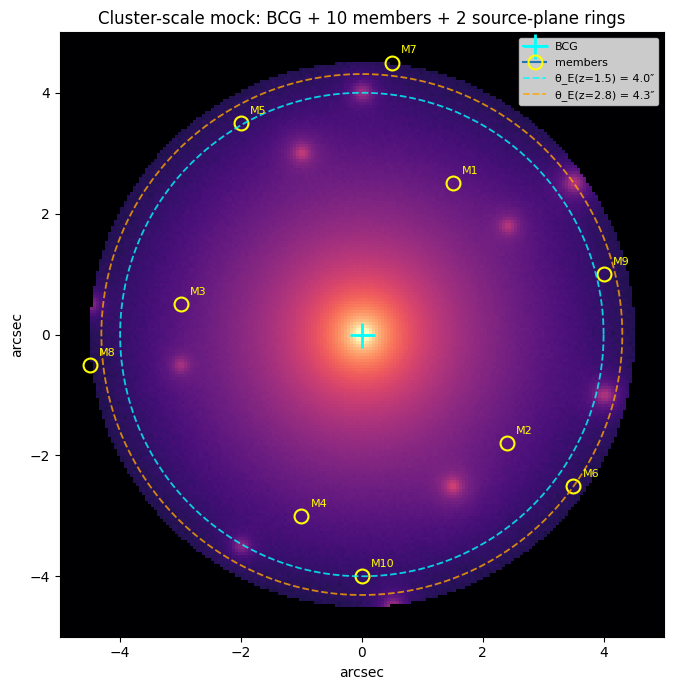

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
extent = [-5.0, 5.0, -5.0, 5.0]
ax.imshow(
    np.log10(np.maximum(dataset.data.native, 1e-3)),
    cmap="magma", origin="lower", extent=extent, vmin=-1, vmax=2,
)
ax.plot(0, 0, marker="+", color="cyan", markersize=18, mew=2, label="BCG")
for i, m in enumerate(truth["members"]):
    cy, cx = m["centre"]
    ax.plot(cx, cy, marker="o", mfc="none", mec="yellow", markersize=10, mew=1.5,
            label="members" if i == 0 else None)
    ax.text(cx + 0.15, cy + 0.15, f"M{i+1}", color="yellow", fontsize=8)
th = np.linspace(0, 2*np.pi, 200)
ax.plot(theta_E_at_s1*np.cos(th), theta_E_at_s1*np.sin(th), "--", color="cyan",
        lw=1.3, alpha=0.8, label=f"θ_E(z={z_s1}) = {theta_E_at_s1:.1f}″")
ax.plot(theta_E_at_s2*np.cos(th), theta_E_at_s2*np.sin(th), "--", color="orange",
        lw=1.3, alpha=0.8, label=f"θ_E(z={z_s2}) = {theta_E_at_s2:.1f}″")
ax.set_aspect("equal")
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_xlabel('arcsec'); ax.set_ylabel('arcsec')
ax.set_title("Cluster-scale mock: BCG + 10 members + 2 source-plane rings")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

---

## 2. Compose a model with extra_galaxies + Faber-Jackson scaling

**Strategy.** 11 individual galaxy mass models (BCG + 10 members) would mean 33+ free mass parameters — impractical. Instead use the standard cluster-lensing pattern from `autolens_workspace_latest/scripts/imaging/features/scaling_relation/modeling.py`:

- **BCG** modeled individually with full SersicSph + IsothermalSph (5 free params).
- **10 members** in `extra_galaxies`, each with `IsothermalSph` mass at fixed photometric centre. Their $\theta_{E,i}$ are *not independent*: they share a single $\theta_{E,*}$ amplitude, and each member's $\theta_{E,i}$ is computed as $\theta_{E,*} \cdot (L_i/L_*)^{0.5}$ (Faber-Jackson). So the 10 members contribute only **1 free parameter** total instead of 10.
- **2 sources** at different redshifts, each `SersicCore` with its own light parameters.

Total free parameters: ~25 (BCG 5 + member-FJ amplitude 1 + source 1: 7 + source 2: 7 + source-1 centre 2 + source-2 centre 2 + assorted ellipticities). Manageable for Nautilus.

In [4]:
# BCG: SersicSph light + IsothermalSph mass
bcg_bulge = af.Model(al.lp.SersicSph)
bcg_bulge.centre = (0.0, 0.0)  # fixed at photometric origin
bcg_bulge.intensity        = af.LogUniformPrior(lower_limit=1e-2, upper_limit=10.0)
bcg_bulge.effective_radius = af.UniformPrior(lower_limit=0.5, upper_limit=4.0)
bcg_bulge.sersic_index     = af.UniformPrior(lower_limit=2.0, upper_limit=6.0)

bcg_mass = af.Model(al.mp.IsothermalSph)
bcg_mass.centre = (0.0, 0.0)  # fixed at photometric origin
bcg_mass.einstein_radius = af.UniformPrior(lower_limit=2.0, upper_limit=6.0)

bcg = af.Model(al.Galaxy, redshift=z_l, bulge=bcg_bulge, mass=bcg_mass)

# Faber-Jackson amplitude (shared across all members)
theta_E_star = af.UniformPrior(lower_limit=0.1, upper_limit=2.0)
L_star = 1.0

members_dict = {}
for i, m in enumerate(truth["members"]):
    cy, cx = m["centre"]
    L_i = m["luminosity"]
    member_mass = af.Model(al.mp.IsothermalSph)
    member_mass.centre = (cy, cx)  # fixed photometric centre
    # FJ scaling: theta_E_i = theta_E_star * sqrt(L_i / L_star)
    member_mass.einstein_radius = theta_E_star * float(np.sqrt(L_i / L_star))
    member = af.Model(al.Galaxy, redshift=z_l, mass=member_mass)
    members_dict[f"member_{i+1}"] = member

# Two sources at different redshifts
def _src_model(z):
    s = af.Model(al.lp.SersicCore)
    s.centre.centre_0 = af.GaussianPrior(mean=0.0, sigma=0.5)
    s.centre.centre_1 = af.GaussianPrior(mean=0.0, sigma=0.5)
    s.intensity        = af.LogUniformPrior(lower_limit=1e-2, upper_limit=10.0)
    s.effective_radius = af.UniformPrior(lower_limit=0.05, upper_limit=0.3)
    s.sersic_index     = af.UniformPrior(lower_limit=0.5, upper_limit=3.0)
    s.ell_comps.ell_comps_0 = af.GaussianPrior(mean=0.0, sigma=0.3)
    s.ell_comps.ell_comps_1 = af.GaussianPrior(mean=0.0, sigma=0.3)
    return af.Model(al.Galaxy, redshift=z, bulge=s)

source_1 = _src_model(z_s1)
source_2 = _src_model(z_s2)

model = af.Collection(
    galaxies=af.Collection(bcg=bcg, source_1=source_1, source_2=source_2),
    extra_galaxies=af.Collection(**members_dict),
)
print(f"Cluster-scale model: {model.prior_count} free parameters")
print(f"  BCG (Sersic+Iso, centre fixed): 4 free params (intensity, R_eff, n, θ_E)")
print(f"  10 members (FJ-scaled, shared θ_E_star): 1 shared free param across all 10")
print(f"  source_1 (SersicCore at z={z_s1}): {source_1.prior_count} free params")
print(f"  source_2 (SersicCore at z={z_s2}): {source_2.prior_count} free params")
print(f"  Total: 4 + 1 + {source_1.prior_count} + {source_2.prior_count} = {model.prior_count}")
print()
print(f"Without FJ scaling, 10 members would each contribute 1 (θ_E) — adding 9 extra")
print(f"free params for a total of {model.prior_count + 9}. FJ saves 9 dimensions.")

Cluster-scale model: 19 free parameters
  BCG (Sersic+Iso, centre fixed): 4 free params (intensity, R_eff, n, θ_E)
  10 members (FJ-scaled, shared θ_E_star): 1 shared free param across all 10
  source_1 (SersicCore at z=1.5): 7 free params
  source_2 (SersicCore at z=2.8): 7 free params
  Total: 4 + 1 + 7 + 7 = 19

Without FJ scaling, 10 members would each contribute 1 (θ_E) — adding 9 extra
free params for a total of 28. FJ saves 9 dimensions.


---

## 3. Skip-guarded fit

At ~25 free parameters and ~64k masked pixels (4.5″ radius @ 0.05″/px), a Nautilus fit at `n_live=200` would take 12+ hours on Cannon. The cell below builds the analysis + search but skips the actual fit unless `LTA_RUN_HEAVY=1`. The Cannon driver `Modules/10_Cluster_Computing/scripts/fit_example_cluster_scale.py` (planned) would be the production submission.

In [5]:
analysis = al.AnalysisImaging(dataset=dataset)
search = af.Nautilus(
    path_prefix=Path("output") / "cluster_scale",
    name="direct_fit",
    n_live=200,
    n_batch=50,
)
if not os.environ.get("PYAUTOFIT_TEST_MODE") and os.environ.get("LTA_RUN_HEAVY"):
    result = search.fit(model=model, analysis=analysis)
else:
    print("[skip-mode] cluster-scale model construction verified.")
    print("  Set LTA_RUN_HEAVY=1 to run the full Nautilus fit (~12h).")
    print("  Recommended path: submit on Cannon via")
    print("    sbatch --time=24:00:00 --export=ALL,EXAMPLE=cluster_scale,FIT_EXTRA_ARGS='' \\")
    print("        Modules/10_Cluster_Computing/scripts/submit_cannon.slurm")
    print("  (driver fit_example_cluster_scale.py to be added.)")

[skip-mode] cluster-scale model construction verified.
  Set LTA_RUN_HEAVY=1 to run the full Nautilus fit (~12h).
  Recommended path: submit on Cannon via
    sbatch --time=24:00:00 --export=ALL,EXAMPLE=cluster_scale,FIT_EXTRA_ARGS='' \
        Modules/10_Cluster_Computing/scripts/submit_cannon.slurm
  (driver fit_example_cluster_scale.py to be added.)


---

## 4. Hand-off

**Recommended next reading:**

- [`README.md`](README.md) — full architectural roadmap including planned variants (`02_multi_source_cosmography.ipynb`, `03_substructure_sensitivity.ipynb`)
- [`../group_scale/00_climb_to_group.ipynb`](../group_scale/00_climb_to_group.ipynb) — sub-architecture climb (BGG + N satellites)
- [`../double_source_plane/00_climb_to_dspl.ipynb`](../double_source_plane/00_climb_to_dspl.ipynb) — sub-architecture climb (multi-source-plane β cosmography)
- `autolens_workspace_latest/scripts/imaging/features/scaling_relation/modeling.py` — Faber-Jackson scaling-relation API (the technique this notebook depends on)
- Caminha+22, Bergamini+23 — modern cluster lensing cosmography references

---

*Learning to Autolens — Examples / cluster_scale / 01 (minimal direct fit)*  
*Rodrigo Córdova Rosado, Harvard CfA*